# Assignment 04 — 03: Final Comparison & Figures
**Track 1 / Option A** | Base vs best-SFT vs best-DPO.

Group: **Abdullah Iqbal (26904), Anushe Ali (26418)**

Loads the saved result JSONs and produces the comparison table, bar charts, and
qualitative side-by-side examples for the report.

## 1. Mount & load results

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJ = '/content/drive/MyDrive/assignment-4'   # change if you like
os.makedirs(PROJ + '/results', exist_ok=True)
os.makedirs(PROJ + '/adapters', exist_ok=True)
print('Saving outputs to', PROJ)

Mounted at /content/drive
Saving outputs to /content/drive/MyDrive/assignment-4


In [2]:
import json, pandas as pd
baseline = json.load(open(PROJ + '/results/baseline.json'))
sft = json.load(open(PROJ + '/results/sft_trials.json'))
dpo = json.load(open(PROJ + '/results/dpo_trials.json'))
best_sft = [t for t in sft['trials'] if t['trial'] == sft['best_trial']][0]
best_dpo = [t for t in dpo['trials'] if t['trial'] == dpo['best_trial']][0]

## 2. Headline comparison table

In [3]:
summary = pd.DataFrame([
    {'stage':'Base',     'BLEU': baseline['metrics']['bleu'], 'BERTScore_F1': baseline['metrics']['bertscore_f1']},
    {'stage':'SFT (best)','BLEU': best_sft['bleu'],            'BERTScore_F1': best_sft['bertscore_f1']},
    {'stage':'DPO (best)','BLEU': best_dpo['bleu'],            'BERTScore_F1': best_dpo['bertscore_f1']},
])
display(summary)
summary.to_csv(PROJ + '/results/summary.csv', index=False)

,stage,BLEU,BERTScore_F1
0,Base,9.816461,0.880325
1,SFT (best),9.465842,0.883640
2,DPO (best),11.937368,0.886262


## 3. Bar charts

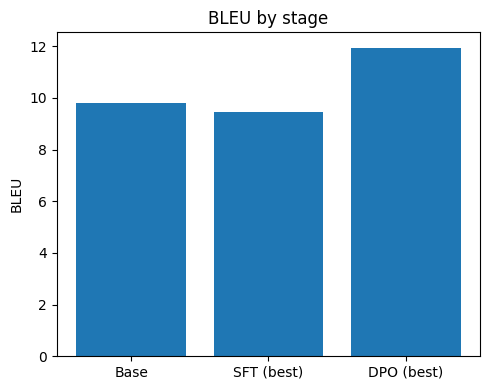

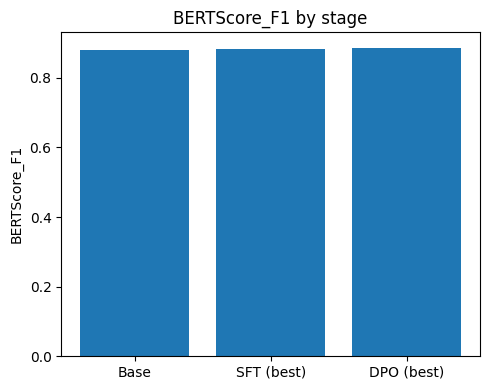

In [4]:
import matplotlib.pyplot as plt
import os
FIG = PROJ + '/figures'; os.makedirs(FIG, exist_ok=True)
for metric in ['BLEU', 'BERTScore_F1']:
    plt.figure(figsize=(5,4))
    plt.bar(summary['stage'], summary[metric])
    plt.title(metric + ' by stage'); plt.ylabel(metric)
    plt.tight_layout(); plt.savefig(f'{FIG}/{metric}_by_stage.png', dpi=150)
    plt.show()

## 4. Per-trial tables (for the report appendix)

In [5]:
sft_df = pd.DataFrame([{k:t[k] for k in ['trial','bleu','bertscore_f1','composite','val_loss']} for t in sft['trials']])
dpo_df = pd.DataFrame([{k:t[k] for k in ['trial','bleu','bertscore_f1','composite','val_loss']} for t in dpo['trials']])
print('SFT trials:'); display(sft_df)
print('DPO trials:'); display(dpo_df)

SFT trials:


,trial,bleu,bertscore_f1,composite,val_loss
0,1,6.115311,0.875189,0.468171,NaN
1,2,6.116716,0.878470,0.469818,NaN
2,3,9.465842,0.883640,0.489149,NaN
3,4,6.565772,0.875503,0.470580,2.125044
4,5,5.770018,0.872104,0.464902,2.107723


DPO trials:


,trial,bleu,bertscore_f1,composite,val_loss
0,1,9.907075,0.885431,0.492251,0.646536
1,2,10.072455,0.880715,0.490720,0.818026
2,3,11.937368,0.886262,0.502818,0.638905
3,4,10.739536,0.889067,0.498231,0.855347
4,5,11.613886,0.889329,0.502734,0.646279


## 5. Qualitative examples (base vs SFT vs DPO)

In [6]:
for i in range(len(baseline['rows'])):
    q = baseline['rows'][i]['instruction']
    print('='*80); print('Q:', q)
    print('\n[BASE]', baseline['rows'][i]['response'][:400])
    print('\n[SFT ]', best_sft['rows'][i]['response'][:400])
    print('\n[DPO ]', best_dpo['rows'][i]['response'][:400])
    print()

Q: Explain the difference between supervised and unsupervised learning in simple terms.

[BASE] Supervised learning and unsupervised learning are two types of machine learning algorithms used to train models on data. In supervised learning, the model is trained on labeled data, meaning that each input is paired with a corresponding output. The goal is to learn a mapping from inputs to outputs so that the model can make accurate predictions on new, unseen data. Examples of supervised learning

[SFT ] Supervised learning is a type of machine learning where the model is trained on a labeled dataset. The model learns to map inputs to outputs based on the patterns in the training data. For example, a supervised learning model could be trained on a dataset of images and their corresponding labels (e.g., "cat" or "dog"). Once trained, the model can be used to classify new images based on the pattern

[DPO ] Supervised learning and unsupervised learning are two types of machine learning approa